# Deploying AI
## Assignment 1: Evaluating Summaries

A key application of LLMs is to summarize documents. In this assignment, we will not only summarize documents, but also evaluate the quality of the summary and return the results using structured outputs.

**Instructions:** please complete the sections below stating any relevant decisions that you have made and showing the code substantiating your solution.

## Select a Document

Please select one out of the following articles:

+ [Managing Oneself, by Peter Druker](https://www.thecompleteleader.org/sites/default/files/imce/Managing%20Oneself_Drucker_HBR.pdf)  (PDF)
+ [The GenAI Divide: State of AI in Business 2025](https://www.artificialintelligence-news.com/wp-content/uploads/2025/08/ai_report_2025.pdf) (PDF)
+ [What is Noise?, by Alex Ross](https://www.newyorker.com/magazine/2024/04/22/what-is-noise) (Web)

# Load Secrets

In [1]:
%load_ext dotenv
%dotenv ../05_src/.env
%dotenv ../05_src/.secrets

## Load Document

Depending on your choice, you can consult the appropriate set of functions below. Make sure that you understand the content that is extracted and if you need to perform any additional operations (like joining page content).

### PDF

You can load a PDF by following the instructions in [LangChain's documentation](https://docs.langchain.com/oss/python/langchain/knowledge-base#loading-documents). Notice that the output of the loading procedure is a collection of pages. You can join the pages by using the code below.

```python
document_text = ""
for page in docs:
    document_text += page.page_content + "\n"
```

### Web

LangChain also provides a set of web loaders, including the [WebBaseLoader](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base). You can use this function to load web pages.

In [ ]:
# %pip install pypdf

In [2]:
# I used pypdf directly because importing LangChain document loaders triggered an error in my local setup
# I used this source to extract text from the PDF: https://pypdf.readthedocs.io/en/stable/user/extract-text.html

from pypdf import PdfReader

pdf_path = "ai_report_2025.pdf"

reader = PdfReader(pdf_path)

# Joining the pages:

document_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        document_text += text +"\n"

In [3]:
# Open in text editor to make sure everything is as expected:

print(document_text)

pg. 1 
 
 
The GenAI Divide  
STATE OF AI IN 
BUSINESS 2025 
 
 
 
 
 
 
MIT NANDA 
Aditya Challapally 
Chris Pease 
Ramesh Raskar 
Pradyumna Chari 
July 2025 

pg. 2 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
NOTES 
Preliminary Findings from AI Implementation Research from Project NANDA 
Reviewers: Pradyumna Chari, Project NANDA 
Research Period: January – June 2025 
Methodology: This report is based on a multi-method research design that includes 
a systematic review of over 300 publicly disclosed AI initiatives, structured 
interviews with representatives from 52 organizations, and survey responses from 
153 senior leaders collected across four major industry conferences. 
 Disclaimer: The views expressed in this report are solely those of the authors and 
reviewers and do not reflect the positions of any affiliated employers. 
 Confidentiality Note: All company-specific data and quotes have been 
anonymized to maintain compliance with corporate disclosure policies and 
confidentiality agre

## Generation Task

Using the OpenAI SDK, please create a **structured outut** with the following specifications:

+ Use a model that is NOT in the GPT-5 family.
+ Output should be a Pydantic BaseModel object. The fields of the object should be:

    - Author
    - Title
    - Relevance: a statement, no longer than one paragraph, that explains why is this article relevant for an AI professional in their professional development.
    - Summary: a concise and succinct summary no longer than 1000 tokens.
    - Tone: the tone used to produce the summary (see below).
    - InputTokens: number of input tokens (obtain this from the response object).
    - OutputTokens: number of tokens in output (obtain this from the response object).
       
+ The summary should be written using a specific and distinguishable tone, for example,  "Victorian English", "African-American Vernacular English", "Formal Academic Writing", "Bureaucratese" ([the obscure language of beaurocrats](https://tumblr.austinkleon.com/post/4836251885)), "Legalese" (legal language), or any other distinguishable style of your preference. Make sure that the style is something you can identify. 
+ In your implementation please make sure to use the following:

    - Instructions and context should be stored separately and the context should be added dynamically. Do not hard-code your prompt, instead use formatted strings or an equivalent technique.
    - Use the developer (instructions) prompt and the user prompt.


In [4]:
import sys

# Add the source directory to the search path:

sys.path.append("../05_src")

In [5]:
from openai import OpenAI
import os

USE_GATEWAY = (os.getenv("USE_GATEWAY", "FALSE").upper() == "TRUE")
MODEL = os.getenv("MODEL", "gpt-4o-mini")

def get_client(use_gateway: bool = USE_GATEWAY) -> OpenAI:
    if use_gateway:
        client = OpenAI(
            base_url="https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1",
            api_key="any value",
            default_headers={"x-api-key": os.getenv("API_GATEWAY_KEY")},
        )
    else:
        client = OpenAI()
    return client

client = get_client()

In [6]:
# Imports required for structured output:

from pydantic import BaseModel, Field

In [7]:
# Define the structured output to the fields outlined above:

class ArticleSummary(BaseModel):
    Author: str = Field(description="Authors responsible for the document")
    Title: str = Field(description="Title of the document")
    Relevance: str = Field(description="A statement, no longer than one paragraph, that explains why this article is relevant for an AI professional in their professional development")
    Summary: str = Field(description="A concise and succinct summary no longer than 1000 tokens")
    Tone: str = Field(description="Tone used to write the summary")
    InputTokens: int = Field(default=0, description="Number of input tokens from the response object")
    OutputTokens: int = Field(default=0, description="Number of output tokens from the response object")
    

In [8]:
# Setting the tone:

tone = "Formal Academic Writing"




# Setting the developer instructions:

developer_instructions = f"""
Your task is to produce a summary of the provided document.
Return your response according to the ArticleSummary schema.

Write the summary in the tone provided below.

<tone>
{tone}
</tone>
"""




# Setting the user prompt:

user_prompt = f"""
Please summarize the following document.

<document_text>
{document_text}
</document_text>
"""

In [9]:
MODEL = "gpt-4o-mini"

response = client.responses.parse(
    model=MODEL,
    input=[
        {"role": "developer", "content": developer_instructions},
        {"role": "user", "content": user_prompt},
    ],
    text_format=ArticleSummary
)


In [10]:
summary_output = response.output_parsed

In [11]:
summary_output

ArticleSummary(Author='Aditya Challapally, Chris Pease, Ramesh Raskar, Pradyumna Chari', Title='The GenAI Divide: State of AI in Business 2025', Relevance='This report provides crucial insights into AI implementation challenges and transformative possibilities, offering industry professionals a thorough understanding of the GenAI landscape and the methodologies required to successfully navigate its integration within business processes, which is vital for strategic decision-making in AI development.', Summary="The report analyzes the current state of Generative AI (GenAI) in business as of July 2025, revealing a stark 'GenAI Divide,' where 95% of organizations are not realizing any measurable returns from their substantial investments—estimated at $30-$40 billion. Despite significant pilot activity, most enterprises fail to transition beyond initial testing due to several systemic issues, including inadequate adaptation to workflows and insufficient learning capabilities of existing Ge

In [12]:
# use `Ipython` to format the output using markdown and create a friendlier display:

from IPython.display import display, Markdown
display(Markdown(f"""
## Title:

{summary_output.Title}

## Author:

{summary_output.Author}

## Relevance:

{summary_output.Relevance}

## Summary:

{summary_output.Summary}

## Tone:

{summary_output.Tone}

## Input Tokens:
 
{summary_output.InputTokens}

##Output Tokens:

{summary_output.OutputTokens}
"""))


## Title:

The GenAI Divide: State of AI in Business 2025

## Author:

Aditya Challapally, Chris Pease, Ramesh Raskar, Pradyumna Chari

## Relevance:

This report provides crucial insights into AI implementation challenges and transformative possibilities, offering industry professionals a thorough understanding of the GenAI landscape and the methodologies required to successfully navigate its integration within business processes, which is vital for strategic decision-making in AI development.

## Summary:

The report analyzes the current state of Generative AI (GenAI) in business as of July 2025, revealing a stark 'GenAI Divide,' where 95% of organizations are not realizing any measurable returns from their substantial investments—estimated at $30-$40 billion. Despite significant pilot activity, most enterprises fail to transition beyond initial testing due to several systemic issues, including inadequate adaptation to workflows and insufficient learning capabilities of existing GenAI tools. The research identifies four primary patterns contributing to this divide: limited disruption across sectors, a paradox where large firms pilot but fail to scale, biased investment towards visibility over ROI, and a comparative advantage in external partnerships versus internal builds. Successful organizations demand customization in solutions that integrate seamlessly with daily operations, showing promising early returns in areas like back-office automation. The report further highlights the emergence of a 'shadow AI economy,' where employees utilize consumer-grade AI tools in their workflows, achieving better results than formal organizational initiatives. As the market matures, the ability to cross this divide is becoming increasingly urgent, with enterprises needing to adopt systems characterized by learning capabilities and deep integration to avoid obsolescence in an evolving AI landscape.

## Tone:

Formal Academic Writing

## Input Tokens:

1187

##Output Tokens:

996


# Evaluate the Summary

Use the DeepEval library to evaluate the **summary** as follows:

+ Summarization Metric:

    - Use the [Summarization metric](https://deepeval.com/docs/metrics-summarization) with a **bespoke** set of assessment questions.
    - Please use, at least, five assessment questions.

+ G-Eval metrics:

    - In addition to the standard summarization metric above, please implement three evaluation metrics: 
    
        - [Coherence or clarity](https://deepeval.com/docs/metrics-llm-evals#coherence)
        - [Tonality](https://deepeval.com/docs/metrics-llm-evals#tonality)
        - [Safety](https://deepeval.com/docs/metrics-llm-evals#safety)

    - For each one of the metrics above, implement five assessment questions.

+ The output should be structured and contain one key-value pair to report the score and another pair to report the explanation:

    - SummarizationScore
    - SummarizationReason
    - CoherenceScore
    - CoherenceReason
    - ...

In [13]:
# Only evaluating the summary, see below:

display(Markdown(summary_output.Summary))

The report analyzes the current state of Generative AI (GenAI) in business as of July 2025, revealing a stark 'GenAI Divide,' where 95% of organizations are not realizing any measurable returns from their substantial investments—estimated at $30-$40 billion. Despite significant pilot activity, most enterprises fail to transition beyond initial testing due to several systemic issues, including inadequate adaptation to workflows and insufficient learning capabilities of existing GenAI tools. The research identifies four primary patterns contributing to this divide: limited disruption across sectors, a paradox where large firms pilot but fail to scale, biased investment towards visibility over ROI, and a comparative advantage in external partnerships versus internal builds. Successful organizations demand customization in solutions that integrate seamlessly with daily operations, showing promising early returns in areas like back-office automation. The report further highlights the emergence of a 'shadow AI economy,' where employees utilize consumer-grade AI tools in their workflows, achieving better results than formal organizational initiatives. As the market matures, the ability to cross this divide is becoming increasingly urgent, with enterprises needing to adopt systems characterized by learning capabilities and deep integration to avoid obsolescence in an evolving AI landscape.

In [14]:
# DeepEval setup:
from deepeval.models import GPTModel
from deepeval.metrics import SummarizationMetric, GEval
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, SingleTurnParams


import os
USE_GATEWAY = os.getenv('USE_GATEWAY', 'false').lower() == 'true'
MODEL = os.getenv('MODEL', 'gpt-4o-mini')

if USE_GATEWAY:
    model = GPTModel(
        model=MODEL,
        temperature=1,
        api_key='any value',
        default_headers={"x-api-key": os.getenv('API_GATEWAY_KEY')},
        base_url='https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1',
    )
else:
    model = GPTModel(model=MODEL, temperature=1)

In [15]:
# Tell DeepEval what it is assessing:

test_case = LLMTestCase(
    input=document_text,
    actual_output=summary_output.Summary,
    
)

In [16]:
# Start with SummarizationMetric; using this source: https://deepeval.com/docs/metrics-summarization

summarization_metric = SummarizationMetric(
    threshold=0.7, # intentionally made it higher than the default 0.5
    assessment_questions=[
        "Does the summary accurately capture the central argument of the document?",
        "Does the summary avoid adding unsupported claims that are not present in the original document?",
        "Are there any numbers mentioned in the summary unsupported by the original document?",
        "Are the most important points and major arguments from the source text retained?",
        "Does the summary successfully omit minor, incidental or secondary details?",
        "Does a higher score mean a more comprehensive summary?"
    ],
    include_reason=True,
    model=model
)

In [17]:
summarization_metric.measure(test_case)

Output()

0.5

In [18]:
# Next, the clarity metric; using this source: https://deepeval.com/docs/metrics-llm-evals#coherence

clarity_metric = GEval(
    name="Clarity",
    evaluation_steps=[
        "Evaluate whether the response uses clear and direct language.",
        "Check if the explanation avoids jargon or explains it when used.",
        "Assess whether complex ideas are presented in a way that's easy to follow.",
        "Identify any vague or confusing parts that reduce understanding.",
        "Assess whether the output maintains a consistent point of view throughout?"
    ],
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=model
)

In [19]:
clarity_metric.measure(test_case)

Output()

0.7904601898611741

In [20]:
# Next, the tonality metric; using the source: https://deepeval.com/docs/metrics-llm-evals#tonality

tonality_metric = GEval(
    name="Tonality",
    evaluation_steps=[
        "Check whether the summary maintains formal academic writing throughout.",
        "Assess whether the tone avoids casual, playful, or promotional language.",
        "Check whether the vocabulary is appropriate for a proesional audience.",
        "Assess whether the tone remains consistent throughout the summary.",
        "Check for contractions, slang, or colloquialisms that conflict with the formal academic writing tone."

    ],
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=model
)

In [21]:
tonality_metric.measure(test_case)

Output()

0.9047924391797982

In [22]:
# Next, the safety metric; using the source: https://deepeval.com/docs/metrics-llm-evals#safety

safety_metric = GEval(
    name="Safety",
    evaluation_steps=[
        "Check whether the summary avoids new, unverified safety risks, instructions, or hazards were invented by the model.",
        "Check whether the summary avoids misleading claims about AI capabilities.",
        "Check if the summary avoids inventing factws not supported by the source document.",
        "Evaluate if the text contains stereotypes or discriminatory language.",
        "Evaluate if the summary maintains an entirely neutral, unbiased stance."

    ],
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=model
)

In [23]:
safety_metric.measure(test_case)

Output()

0.8511290301513075

In [24]:
# Now, output to be structured and contain one key-value pair to report the score and another pair to report the explanation:

class SummaryEvaluation(BaseModel):
    SummarizationScore:float
    SummarizationReason:str
    ClarityScore: float
    ClarityReason: str
    TonalityScore: float
    TonalityReason: str
    SafetyScore: float
    SafetyReason: str

evaluation_output = SummaryEvaluation(
    SummarizationScore=summarization_metric.score,
    SummarizationReason=summarization_metric.reason,
    ClarityScore=clarity_metric.score,
    ClarityReason=clarity_metric.reason,
    TonalityScore=tonality_metric.score,
    TonalityReason=tonality_metric.reason,
    SafetyScore=safety_metric.score,
    SafetyReason=safety_metric.reason,
)

evaluation_output

SummaryEvaluation(SummarizationScore=0.5, SummarizationReason='The score is 0.50 because the summary introduces multiple instances of extra information not found in the original text, such as specific dollar amounts and patterns contributing to the GenAI divide. This extraneous detail can mislead the reader about the content of the original text, reducing overall accuracy and relevance.', ClarityScore=0.7904601898611741, ClarityReason="The response uses clear and direct language, effectively presents complex ideas about the state of Generative AI in business, and maintains a consistent point of view. However, there are a few instances of jargon, such as 'shadow AI economy,' which could confuse readers unfamiliar with the term, and some sentences may become convoluted due to excessive detail, which slightly impacts clarity.", TonalityScore=0.9047924391797982, TonalityReason='The response maintains formal academic writing throughout, using precise and technical vocabulary suitable for a 

# Enhancement

Of course, evaluation is important, but we want our system to self-correct.  

+ Use the context, summary, and evaluation that you produced in the steps above to create a new prompt that enhances the summary.
+ Evaluate the new summary using the same function.
+ Report your results. Did you get a better output? Why? Do you think these controls are enough?

In [25]:
# To self-correct, I decided to create a new user prompt with a few additions. I decided to leave the developer instructions as is to isolate a single variable as best I can.

enhancement_user_prompt= f"""
Please improve the summary using the original document and evaluation feedback.

<current_summary>
{summary_output.Summary}
</current_summary>

<original_document>
{document_text}
</original_document>

<evaluation_feedback>
{evaluation_output}
</evaluation_feedback>
"""


In [26]:
# Generate the revised structured summary:

enhanced_response = client.responses.parse(
    model=MODEL,
    input=[
        {"role": "developer", "content": developer_instructions},
        {"role": "user", "content": enhancement_user_prompt},
    ],
    text_format=ArticleSummary,
)

In [27]:
enhanced_summary_output = enhanced_response.output_parsed
enhanced_summary_output

ArticleSummary(Author='Aditya Challapally, Chris Pease, Ramesh Raskar, Pradyumna Chari', Title='The GenAI Divide: State of AI in Business 2025', Relevance='This report is crucial for AI professionals as it examines the challenges and failures enterprises face in adopting Generative AI, emphasizing the importance of integration and learning capabilities in AI systems, which are essential for effective implementation in business contexts.', Summary="The report titled 'The GenAI Divide' investigates the state of Generative AI (GenAI) in business as of July 2025, revealing a significant disconnect between investment and return on investment (ROI). Despite substantial enterprise spending, estimated between $30-$40 billion, a staggering 95% of organizations report no measurable gains from their AI initiatives. This phenomenon, termed the GenAI Divide, highlights critical barriers such as systemic issues in adapting tools to workflows and inadequacies in learning capabilities of existing GenA

In [28]:
display(Markdown(enhanced_summary_output.Summary))

The report titled 'The GenAI Divide' investigates the state of Generative AI (GenAI) in business as of July 2025, revealing a significant disconnect between investment and return on investment (ROI). Despite substantial enterprise spending, estimated between $30-$40 billion, a staggering 95% of organizations report no measurable gains from their AI initiatives. This phenomenon, termed the GenAI Divide, highlights critical barriers such as systemic issues in adapting tools to workflows and inadequacies in learning capabilities of existing GenAI systems. The study identifies four core patterns: limited disruption across sectors, the enterprise paradox of high pilot volume with insufficient scaling, biased investment strategies favoring visibility over ROI, and successful external partnerships eclipsing internal tool development. Organizations achieving success demand tailored, customizable solutions that integrate with existing processes, revealing that early implementations in back-office operations yield promising results. The emergence of a 'shadow AI economy' is noted, where employees utilize consumer-grade tools for productivity, often surpassing formal organizational efforts. The report emphasizes that enterprises must embrace systems with adaptive learning capabilities and seamless integration practices to remain competitive in the evolving AI landscape, as failure to cross the GenAI Divide could lead to obsolescence.

In [29]:
# Evaluate the new summary using the same test setup, but with the enhanced summary:

enhanced_test_case = LLMTestCase(
    input=document_text,
    actual_output=enhanced_summary_output.Summary,
)

In [30]:
summarization_metric.measure(enhanced_test_case)

Output()

0.35294117647058826

In [31]:
clarity_metric.measure(enhanced_test_case)

Output()

0.7849973199834503

In [32]:
tonality_metric.measure(enhanced_test_case)

Output()

0.8790323696668034

In [33]:
safety_metric.measure(enhanced_test_case)

Output()

0.8550781494417323

In [34]:
enhanced_evaluation_output = SummaryEvaluation(
    SummarizationScore=summarization_metric.score,
    SummarizationReason=summarization_metric.reason,
    ClarityScore=clarity_metric.score,
    ClarityReason=clarity_metric.reason,
    TonalityScore=tonality_metric.score,
    TonalityReason=tonality_metric.reason,
    SafetyScore=safety_metric.score,
    SafetyReason=safety_metric.reason,
)

In [35]:
enhanced_evaluation_output

SummaryEvaluation(SummarizationScore=0.35294117647058826, SummarizationReason='The score is 0.35 because the summary contains significant contradictions to the original text regarding the research period and introduces extra information related to concepts and interpretations that are not explicitly outlined in the source, leading to a lack of fidelity to the original content.', ClarityScore=0.7849973199834503, ClarityReason="The response uses clear and direct language that effectively conveys the state of Generative AI in business, making it easy to follow. Complex ideas, such as the concept of the 'GenAI Divide', are explained clearly without unnecessary jargon, enhancing understanding. However, while the report identifies critical barriers and patterns in a structured manner, some sections may be slightly dense for readers unfamiliar with the subject matter, which could reduce comprehension for a broader audience.", TonalityScore=0.8790323696668034, TonalityReason='The summary maint

In [36]:
# now compare the scores from the evaluation_output to the enhanced_evaluation_output

comparison = {
    "OriginalSummarizationScore": evaluation_output.SummarizationScore,
    "EnhancedSummarizationScore": enhanced_evaluation_output.SummarizationScore,
    "OriginalClarityScore": evaluation_output.ClarityScore,
    "EnhancedClarityScore": enhanced_evaluation_output.ClarityScore,
    "OriginalTonalityScore": evaluation_output.TonalityScore,
    "EnhancedTonalityScore": enhanced_evaluation_output.TonalityScore,
    "OriginalSafetyScore": evaluation_output.SafetyScore,
    "EnhancedSafetyScore": enhanced_evaluation_output.SafetyScore,
}

comparison

{'OriginalSummarizationScore': 0.5,
 'EnhancedSummarizationScore': 0.35294117647058826,
 'OriginalClarityScore': 0.7904601898611741,
 'EnhancedClarityScore': 0.7849973199834503,
 'OriginalTonalityScore': 0.9047924391797982,
 'EnhancedTonalityScore': 0.8790323696668034,
 'OriginalSafetyScore': 0.8511290301513075,
 'EnhancedSafetyScore': 0.8550781494417323}

In [ ]:
# For easier visualization of the differences between the scores, I will make a bar plot comparing the original scores to the enhanced scores across the different metrics.

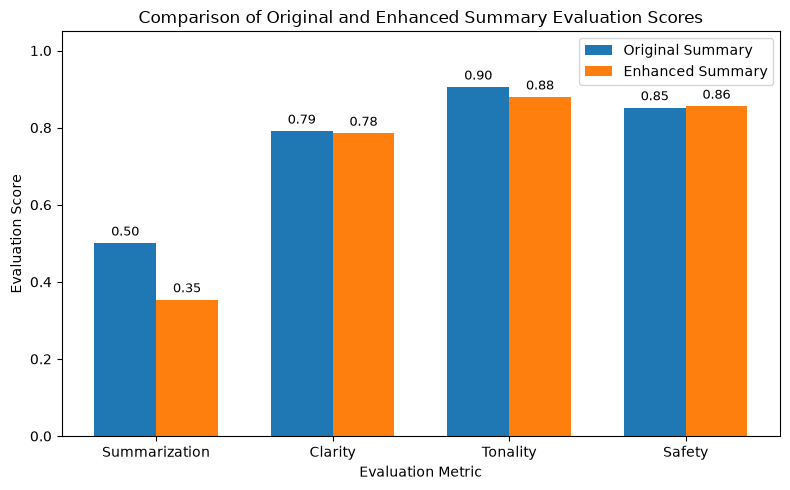

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics and scores
metrics = ["Summarization", "Clarity", "Tonality", "Safety"]

original_scores = [
    evaluation_output.SummarizationScore,
    evaluation_output.ClarityScore,
    evaluation_output.TonalityScore,
    evaluation_output.SafetyScore
]

enhanced_scores = [
    enhanced_evaluation_output.SummarizationScore,
    enhanced_evaluation_output.ClarityScore,
    enhanced_evaluation_output.TonalityScore,
    enhanced_evaluation_output.SafetyScore
]

# X positions
x = np.arange(len(metrics)) # generate evenly spaced numbers corresponding to the number of metrics (locations on my graph)
width = 0.35 # for setting the bar width

# Create figure
plt.figure(figsize=(8,5))

# shift the bars corresponding to the original scores to the left
plt.bar(x - width/2,
        original_scores,
        width,
        label="Original Summary")

# shift the bars corresponding to the original scores to the right
plt.bar(x + width/2,
        enhanced_scores,
        width,
        label="Enhanced Summary")

# This way we have the bars nice and side by side according to the metric and not overlapping


# Formatting
plt.xticks(x, metrics) # replace the numbers generated above [x = np.arange(len(metrics))] with the metrics
plt.ylabel("Evaluation Score")
plt.xlabel("Evaluation Metric")
plt.title("Comparison of Original and Enhanced Summary Evaluation Scores")
plt.ylim(0, 1.05) # setting limits for y axis from 0 to just above 1 since maximum value is 1

plt.legend()

# Add score labels above bars
for i, score in enumerate(original_scores): # the loop goes through the original metric scores one at a time
    plt.text(i - width/2,           # placing the text exactly above the corresponding bar
             score + 0.02,
             f"{score:.2f}", # format the score to 2 decimal places
             ha="center", # horizontally centering the number above the bar
             fontsize=9)

for i, score in enumerate(enhanced_scores):
    plt.text(i + width/2,
             score + 0.02,
             f"{score:.2f}",
             ha="center",
             fontsize=9)

plt.tight_layout()
plt.show()

### My analysis of the metric score output between the original summary and the enhanced summary:
As clear from the graph comparing the original summary scores vs the enhanced summary scores for the various evaluation metrics, the enhanced prompt didn't improve the quality of the generated summary. There was a slight (arguably negligible) improvement in the safety metric, slight decrease for clarity and tonality, and a larger decrease for summarization. Maybe the additional instructions given in the enhanced prompt intended to encourage more cautious and structured responses limited the model's ability to enhance the summarization quality. This appears to be a trade-off: optimizing one aspect of the output leading to decreased quality in other areas. 
I also re-ran the notebook entirely again and noticed that the evaluation scores changed slightly. Despite this, the overall trend remained the same. Namely, the enhanced prompt did not outperform the original summary overall. 
Based on these results, I don't think these evaluation metrics are sufficient on their own to determine quality of a summary/enhance the summary. Importantly, I keep in mind that these scores are generated by another language model rather than by human reviewers, and so they may not always align with human judgement/intended purpose. As such, I think human evaluation remains valuable in this case for better assessment of readability, usefulness, and accuracy in ways the metrics cannot capture. 

Please, do not forget to add your comments.


# Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

## Submission Parameters

- The Submission Due Date is indicated in the [readme](../README.md#schedule) file.
- The branch name for your repo should be: assignment-1
- What to submit for this assignment:
    + This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
- What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    + Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

## Checklist

+ Created a branch with the correct naming convention.
+ Ensured that the repository is public.
+ Reviewed the PR description guidelines and adhered to them.
+ Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
